# W8-1. Feature Selection & SVM

**오늘 할 일**
1. 저번 주 Logistic Regression 흐름을 다시 한 번 따라가 보기
2. `SelectKBest`로 descriptor(=feature) **몇 개**를 쓸지 정하기
3. 같은 개수로 **MLP**, **SVM**도 학습시켜서 성능 비교

> 📝 **descriptor = feature** — 분자 구조를 숫자로 바꾼 값. 동일한 의미.

**데이터**: `skin_irritation_2Ddesc.csv` (저번 시간에 만든 파일)

**구성**
- Part A — 저번 주 코드 복습 (셀 그대로 실행)
- Part B — 이번 주 실습 (✏️ 표시 셀은 직접 채워 넣기)


---
# Part A. 저번 주 복습

셀을 하나씩 `Shift+Enter`로 실행하면서 주석 읽어 봐.


## A-1. 데이터 불러오기

`pandas.read_csv`로 파일 읽고 `df`에 담기.
- `df.shape` → (행, 열)
- `df.head()` → 위 5줄 미리보기

✅ **예상**: `(39, 220)` — 화합물 39개, 열 220개.


In [1]:
import pandas as pd

df = pd.read_csv('skin_irritation_2Ddesc.csv')
print('shape:', df.shape)
df.head()


shape: (39, 220)


,Chemical_Name,standardized_smi,label,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,Heptanal,CCCCCCC=O,1,9.768009,9.768009,0.750000,0.750000,0.395123,9.125000,114.188,...,0,0,0,0,0,0,0,0,4,0
1,4-Methylthio benzaldehyde,CSc1ccc(C=O)cc1,0,10.199308,10.199308,0.734074,0.734074,0.477177,9.300000,152.218,...,1,0,0,0,0,0,0,0,0,0
2,Heptyl butyrate,CCCCCCCOC(=O)CCC,0,10.909695,10.909695,0.043526,-0.043526,0.429221,10.000000,186.295,...,0,0,0,0,0,0,0,0,4,0
3,Hydroxycitronellal,COC(=O)c1ccccc1N=CCC(C)CCCC(C)(C)O,0,11.646816,11.646816,0.369467,-0.590016,0.579721,13.318182,305.418,...,0,0,0,0,0,0,0,0,0,0
4,Methyl caproate,CCCCCC(=O)OC,0,10.464402,10.464402,0.094028,-0.094028,0.427720,9.111111,130.187,...,0,0,0,0,0,0,0,0,2,0


## A-2. X / y 나누고 descriptor 정리

- `y` = `label` 열 (피부 자극: 0/1)
- `X` = 나머지 숫자 descriptor

버릴 거 두 가지:
1. **NaN 있는 열** — 일부 descriptor는 특정 분자에서 계산이 실패해 `NaN`이 돼. 👉 저번 주 마지막에 `clf.fit(X, y)`가 터진 이유가 바로 이거야.
2. **표준편차 0.01 미만 열** — 거의 다 같은 값이면 구분력이 없으니 빼.

✅ **예상**: NaN 제거 `(39, 209)` → std 필터 `(39, 144)`


In [2]:
y = df['label']
X = df.drop(columns=['Chemical_Name', 'standardized_smi', 'label'])

X = X.dropna(axis=1)                 # NaN 열 제거
print('NaN 제거:', X.shape)

X = X.loc[:, X.std() >= 0.01]        # 저분산 제거
print('std 필터:', X.shape)


NaN 제거: (39, 209)
std 필터: (39, 144)


## A-3. 전체 descriptor로 Logistic Regression

일단 다 넣고 돌려 봐.
- `clf.fit(X, y)` : 학습
- `clf.score(X, y)` : 학습 데이터 정확도 — 1.0에 가까워도 좋아하면 안 돼(**overfitting** 의심).
- `cross_val_score(..., cv=5)` : 5등분해서 돌아가며 검증. 진짜 성능은 이쪽.
- 함수 설명: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html
- cross validation 설명: https://scikit-learn.org/stable/modules/cross_validation.html

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

'''
descriptor 단위가 달라서 표준화 (사실 2D descriptor 사용할 때는 normalization이 필수!)
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

standardscaler는 descriptor 값을 평균과 표준편차로 표준화시키는 방법. (나는 고등학교 때 수학 시간에 확률과 통계 시간에 배웠던 것 같은데...)

또 다른 표준화 방식은 descriptor의 최대, 최소 값을 이용하는 것.
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html
'''

X_scaled = StandardScaler().fit_transform(X)   # descriptor값 표준화

clf = LogisticRegression(max_iter=5000)
clf.fit(X_scaled, y)
print('train :', clf.score(X_scaled, y))
print('CV5   :', cross_val_score(clf, X_scaled, y, cv=5).mean().round(3))



train : 0.9743589743589743
CV5   : 0.789


---
# Part B. 이번 주 실습

✏️ 셀 3개를 직접 채워. 바로 위 Part A를 참고하면 충분해.

1. `SelectKBest` + Logistic Regression으로 **최적 K** 찾기
2. 같은 K로 **MLP** — 로지스틱보다 나은가?
3. 같은 K로 **SVM** — `C`, `kernel` 바꿔 보기


## B-0. SelectKBest 개념

> 📌 **성능 숫자 해석 팁**: 샘플이 39개뿐이니까 5-fold CV는 fold당 8개 정도만 들어가. **±0.1 변동은 정상**이야. 미세한 차이로 모델 좋고 나쁨을 단정하지 마.

데이터는 39개, descriptor는 144개. 입력이 너무 많으면 노이즈에 묻혀서 패턴을 못 잡아. `SelectKBest`는 **y와 관련 높은 상위 K개**만 골라.

- 📖 <https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html>

> ⚠️ `SelectKBest(f_classif, ...)`는 스케일 영향을 안 받아서 원본 `X`에 써도 돼. 대신 **모델 학습 직전엔 반드시 `StandardScaler`**. 순서: `SelectKBest` → `StandardScaler` → 모델.

**사용법** (3줄):
```python
from sklearn.feature_selection import SelectKBest, f_classif
selector = SelectKBest(f_classif, k=10)
X_new = selector.fit_transform(X, y)
```

K=10으로 뽑히는 descriptor 이름 먼저 확인.


In [4]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k=10)
selector.fit(X, y)
print(list(X.columns[selector.get_support()]))


['MinAbsEStateIndex', 'BertzCT', 'Chi0', 'Chi1', 'PEOE_VSA7', 'SlogP_VSA6', 'HeavyAtomCount', 'MolMR', 'fr_C_O_noCOO', 'fr_ester']


## ✏️ 실습 1 — Logistic Regression 최적 K

K를 바꿔 가며 5-fold CV 정확도 비교. 제일 높은 K가 **`best_k`**.

**힌트**
1. `for k in k_candidates:` 루프
2. 루프 안에서 `SelectKBest(f_classif, k)` → `StandardScaler` → `LogisticRegression(max_iter=5000)` 의 CV 점수
3. 가장 높은 k를 `best_k`에 저장 (다음 실습에서 재사용)

✅ **경향**: 너무 적으면 정보 부족, 너무 많으면 노이즈.


In [8]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

k_candidates = [5, 10, 15, 20, 25, 30, 40, 50]
best_k, best_score = None, -1

# TODO: 각 k에 대해 SelectKBest → StandardScaler → LogReg CV5
#       k, acc 출력 + best_k/best_score 업데이트
#       예시 출력: 'k=10: 0.793'

for k in k_candidates:
    # 1. feature 선택
    selector = SelectKBest(f_classif, k=k)
    X_sel = selector.fit_transform(X, y)
    
    # 2. 스케일링
    X_scaled = StandardScaler().fit_transform(X_sel)
    
    # 3. 모델 + CV
    clf = LogisticRegression(max_iter=5000)
    score = cross_val_score(clf, X_scaled, y, cv=5).mean()
    
    # 출력
    print(f'k={k}: {score:.3f}')
    
    # best 업데이트
    if score > best_score:
        best_score = score
        best_k = k

print(f'\nBest k = {best_k}, score = {best_score:.3f}')

k=5: 0.668
k=10: 0.793
k=15: 0.793
k=20: 0.793
k=25: 0.743
k=30: 0.743
k=40: 0.664
k=50: 0.661

Best k = 10, score = 0.793


## ✏️ 실습 2 — 같은 K로 MLP

실습 1의 `best_k` 그대로. 모델만 `LogisticRegression` → `MLPClassifier`.

**힌트**
- `from sklearn.neural_network import MLPClassifier`
- `MLPClassifier(random_state=0, max_iter=2000)`
- hidden layer 1개, hidden node 개수는 k와 동일하게 설정
- 데이터가 적으면 MLP가 로지스틱보다 **떨어질 수도** 있어. 그것도 배움이야.


In [9]:
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# TODO: best_k로 SelectKBest → StandardScaler → MLPClassifier(random_state=0, max_iter=2000)
#       CV5 점수 출력 + 실습 1 결과와 한 줄 비교

# 1. feature 선택
selector = SelectKBest(f_classif, k=best_k)
X_sel = selector.fit_transform(X, y)

# 2. 스케일링
X_scaled = StandardScaler().fit_transform(X_sel)

# 3. MLP 모델 (hidden node = k)
mlp = MLPClassifier(hidden_layer_sizes=(best_k,), random_state=0, max_iter=2000)

# 4. CV
mlp_score = cross_val_score(mlp, X_scaled, y, cv=5).mean()

print(f'MLP (k={best_k}) : {mlp_score:.3f}')
print(f'LogReg (k={best_k}) : {best_score:.3f}')

MLP (k=10) : 0.711
LogReg (k=10) : 0.793


## B-3. SVM 개념

SVM은 **두 그룹 사이에 제일 넉넉한 경계선**을 찾아. 경계에 가까운 점(support vector)과의 거리(margin)를 최대로.

핵심 2개만 기억하면 돼.

| 이름 | 역할 | 크면 | 작으면 |
|------|------|------|--------|
| `C` | regularization의 역수 | 학습 데이터에 바짝 맞춤 → overfitting↑ | 경계 부드러움 → underfitting 가능 |
| `kernel` | 경계 모양 | `linear`: 직선 / `rbf`: 종 모양 곡선 / `poly`: 다항식 | — |

- 📖 SVC: <https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html>
- 📖 SVM 해설: <https://scikit-learn.org/stable/modules/svm.html>


## ✏️ 실습 3 — 같은 K로 SVM (`C` × `kernel`)

`best_k`로 descriptor 뽑고, `C`와 `kernel` 조합을 표처럼 찍어 봐.

**힌트**
- `from sklearn.svm import SVC`
- 이중 for: `for C in [0.1, 1, 10]: for kernel in ['linear', 'rbf', 'poly']:`
- RBF/poly는 스케일에 민감 → **`StandardScaler` 필수**
- 💡 `poly`는 경고 뜰 수 있는데 정상. 거슬리면 `import warnings; warnings.filterwarnings('ignore')`.


In [10]:
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# TODO: best_k로 X_sel 만들고, C × kernel 조합 CV5 출력
#       예시 출력: 'C=0.1, kernel=linear : 0.775'

# 1. feature 선택
selector = SelectKBest(f_classif, k=best_k)
X_sel = selector.fit_transform(X, y)

# 2. 스케일링
X_scaled = StandardScaler().fit_transform(X_sel)

# 3. SVM (C × kernel)
for C in [0.1, 1, 10]:
    for kernel in ['linear', 'rbf', 'poly']:
        svm = SVC(C=C, kernel=kernel)
        score = cross_val_score(svm, X_scaled, y, cv=5).mean()
        
        print(f'C={C}, kernel={kernel} : {score:.3f}')

C=0.1, kernel=linear : 0.775
C=0.1, kernel=rbf : 0.668
C=0.1, kernel=poly : 0.668
C=1, kernel=linear : 0.689
C=1, kernel=rbf : 0.746
C=1, kernel=poly : 0.693
C=10, kernel=linear : 0.711
C=10, kernel=rbf : 0.768
C=10, kernel=poly : 0.614


---
## 스스로 확인

세 실습을 다 채워 실행했으면, 아래 질문에 머릿속으로 답해 봐.

- (Q1) 최적 K는 몇? 왜?

      K = 10
      K = 5는 성능 낮음, K = 10~20는 최고 성능, K > 20는 불필요한 feature 증가하면서 성능 감소
      K = 10, 15, 20는 동일 성능이지만 K = 10이 가장 적은 feature를 사용하므로 K = 10이 최적

- (Q2) 같은 K에서 MLP가 로지스틱보다 좋게 나올까? 이유는?

      아니요
      데이터 수 매우 적음
      MLP 복잡한 모델이라 과적합 발생
      로지스틱 단순해서 일반화 잘 됨

  
- (Q3) SVM에서 제일 좋은 `(C, kernel)` 조합은?

      C = 0.1, kernel = 


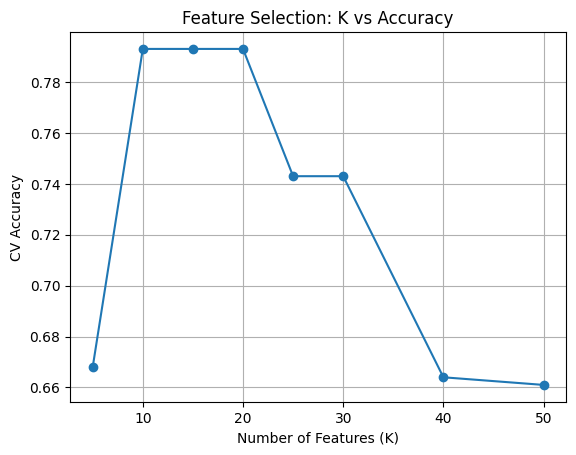

In [11]:
import matplotlib.pyplot as plt

k_candidates = [5, 10, 15, 20, 25, 30, 40, 50]
scores = [0.668, 0.793, 0.793, 0.793, 0.743, 0.743, 0.664, 0.661]

plt.figure()
plt.plot(k_candidates, scores, marker='o')

plt.xlabel('Number of Features (K)')
plt.ylabel('CV Accuracy')
plt.title('Feature Selection: K vs Accuracy')

plt.grid()

plt.show()

In [13]:
import pandas as pd

data = {
    'C': [0.1, 0.1, 0.1, 1, 1, 1, 10, 10, 10],
    'kernel': ['linear', 'rbf', 'poly'] * 3,
    'score': [0.775, 0.668, 0.668, 0.689, 0.746, 0.693, 0.711, 0.768, 0.614]
}

df_svm = pd.DataFrame(data)
df_svm

,C,kernel,score
0,0.1,linear,0.775
1,0.1,rbf,0.668
2,0.1,poly,0.668
3,1.0,linear,0.689
4,1.0,rbf,0.746
5,1.0,poly,0.693
6,10.0,linear,0.711
7,10.0,rbf,0.768
8,10.0,poly,0.614
